In [1]:
# load lib
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import numpy as np
import vectorbt as vbt
import pandas as pd
import numba as nb
import optuna # Import Optuna

# Add backend directory to path for importing app modules
import sys
from pathlib import Path
backend_path = Path(__file__).parent.parent / "backend" if "__file__" in dir() else Path("../backend").resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

In [34]:
## Load datasource from deltalake and save it to local h5 file
REMOTE_HOST = "http://minio.phuchuynh.xyz:9000"

from deltalake import DeltaTable
def load_stock_data() -> pd.DataFrame:
    """Load stock data from delta lake, ensuring index uniqueness to avoid unstack ValueError"""
    try:
        from deltalake import DeltaTable
        storage_options = {
            "AWS_ACCESS_KEY_ID": "CzOwnLkEDXQy951AOqes",
            "AWS_SECRET_ACCESS_KEY": "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S",
            "AWS_ENDPOINT_URL": REMOTE_HOST,
            "AWS_ALLOW_HTTP": "true",
            "AWS_EC2_METADATA_DISABLED": "true",
            "AWS_REGION": 'us-east-1',
            "aws_conditional_put": "etag",
        }        
        dt = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)

        # Get data for last 2 years
        # Load watchlist symbols from CSV
        watchlist_path = "../backend/models/watchlist.csv"
        watchlist_df = pd.read_csv(watchlist_path)
        watchlist_symbols = watchlist_df.iloc[:, 0].values

        now = pd.Timestamp.now()
        start_date = now - pd.DateOffset(years=10)
        # Load all, then filter
        df = dt.to_pandas(
            filters=[("date", ">=", start_date), ("symbol", "in", watchlist_symbols)], 
            columns=["symbol", "date", "close", "open", "high", "low", "volume"]
        )
        
        # Remove duplicate (date, symbol) rows by keeping the last occurrence
        df = df.drop_duplicates(subset=["date", "symbol"], keep="last")
        # Convert to the same format as H5 store
        df = df.set_index(["date", "symbol"])
        stocks = df.unstack(level=1).bfill().ffill()
        
        print("Successfully loaded data from delta lake")
        return stocks
        
    except Exception as e:
        print(f"Error loading from delta lake: {e}")
        raise

import os
import pandas as pd

local_file = "stocks_data_latest.h5"
store_key = "stocks"

if os.path.exists(local_file):
    print(f"Loading stock data from local HDF5 file: {local_file}")
    with pd.HDFStore(local_file, mode="r") as store:
        df = store[store_key]
else:
    print("Local HDF5 file not found, loading stock data from Delta Lake...")
    df = load_stock_data()
    with pd.HDFStore(local_file, mode="w") as store:
        store.put(store_key, df)
    print(f"Stock data saved to {local_file}")

# Filter df to keep only columns for symbols in the watchlist (once)
watchlist_path = "../backend/models/watchlist.csv"
watchlist_df = pd.read_csv(watchlist_path)
watchlist_symbols = watchlist_df.iloc[:, 0].values
# watchlist_symbols = ['VNINDEX']
df = df.loc[:, df.columns.get_level_values('symbol').isin(watchlist_symbols)]
df

Loading stock data from local HDF5 file: stocks_data_latest.h5


close                                                        \
symbol           AAA        ABB        ACB        ACV       ADS        AGG   
date                                                                         
2015-12-28  5.727054   8.201591   3.692765  20.629999  3.940815  15.284813   
2015-12-29  5.828418   8.201591   3.711899  20.629999  3.940815  15.284813   
2015-12-30  6.335237   8.201591   3.731032  20.629999  3.940815  15.284813   
2015-12-31  6.233873   8.201591   3.788433  20.629999  3.940815  15.284813   
2016-01-04  6.385919   8.201591   3.769299  20.629999  3.940815  15.284813   
...              ...        ...        ...        ...       ...        ...   
2025-12-19  8.020000  15.700000  23.900000  51.500000  8.000000  14.400000   
2025-12-22  8.050000  16.000000  24.299999  51.900002  8.010000  14.550000   
2025-12-23  7.970000  15.800000  24.200001  51.599998  8.010000  14.400000   
2025-12-24  7.950000  15.800000  24.299999  50.599998  8.010000  14.400000   
2025-12-25  7.910000  15.700000  24.000000  50.900002  8.000000  14.300000   

                                                       ...       volume  \
symbol            AGR        ANV        APH       ASM  ...      VNINDEX   
date                                                   ...                
2015-12-28   3.110183  17.299999  30.166281  7.303689  ...  100998128.0   
2015-12-29   3.110183  17.299999  30.166281  7.629332  ...   94079184.0   
2015-12-30   3.110183  17.299999  30.166281  7.582811  ...   83672232.0   
2015-12-31   3.110183  17.299999  30.166281  7.675852  ...  102999328.0   
2016-01-04   3.110183  17.299999  30.166281  7.954974  ...   95930576.0   
...               ...        ...        ...       ...  ...          ...   
2025-12-19  16.549999  27.100000   6.420000  6.580000  ...  769377152.0   
2025-12-22  16.700001  27.799999   6.340000  6.620000  ...  755354624.0   
2025-12-23  16.250000  27.299999   6.280000  6.630000  ...  730833984.0   
2025-12-24  16.500000  26.850000   6.350000  6.600000  ...  789923136.0   
2025-12-25  16.350000  26.700001   6.300000  6.580000  ...  803909504.0   

                                                                              \
symbol            VNM       VOS         VPB       VPG        VPI         VRE   
date                                                                           
2015-12-28   821730.0   17090.0  58299312.0    5000.0     5000.0       800.0   
2015-12-29   399590.0    2720.0  58299312.0    5000.0     5000.0       800.0   
2015-12-30   309040.0   23040.0  58299312.0    5000.0     5000.0       800.0   
2015-12-31   688500.0   32170.0  58299312.0    5000.0     5000.0       800.0   
2016-01-04   469320.0   54560.0  58299312.0    5000.0     5000.0       800.0   
...               ...       ...         ...       ...        ...         ...   
2025-12-19  2685700.0  508800.0   9896000.0  381300.0  1472800.0  10546100.0   
2025-12-22  2650700.0  539600.0  13903800.0  143100.0  1730100.0   9656000.0   
2025-12-23  4394700.0  741200.0  12224300.0  150900.0  1795300.0  14877500.0   
2025-12-24  4870200.0  415700.0  15286500.0  242000.0  1499200.0   9103700.0   
2025-12-25  2059600.0  440100.0  14199000.0  238100.0  1714700.0  17089700.0   

                                            
symbol            VSC       VTP        YEG  
date                                        
2015-12-28   213160.0     300.0     6100.0  
2015-12-29    98500.0     300.0     6100.0  
2015-12-30   144540.0     300.0     6100.0  
2015-12-31   284460.0     300.0     6100.0  
2016-01-04   380930.0     300.0     6100.0  
...               ...       ...        ...  
2025-12-19  4302000.0  409800.0  3936500.0  
2025-12-22  5450000.0  267900.0  2657700.0  
2025-12-23  6543700.0  729600.0  3211100.0  
2025-12-24  4043700.0  261500.0  1820700.0  
2025-12-25  6165700.0  335800.0  2096000.0  

[2500 rows x 985 columns]

248 248


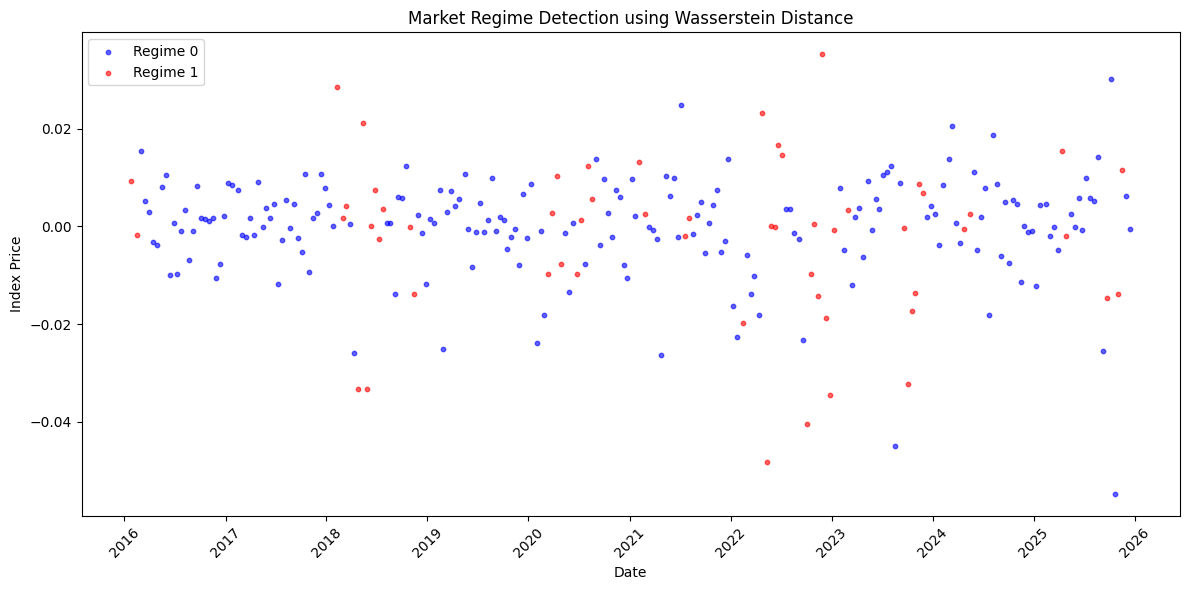

Regime 0: Mean=0.0013, Std=0.0084, Count=193 windows
Regime 1: Mean=-0.0023, Std=0.0188, Count=55 windows


In [43]:
from scipy.stats import wasserstein_distance
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


vnindex_close = df.close['VNINDEX']

# Calculate daily returns
daily_returns = vnindex_close.pct_change().dropna()

# Calculate cumulative returns
cumulative_returns = (1 + daily_returns).cumprod() - 1

# Create rolling windows
window_size = 20
step_size = 10
segments = []
segment_dates = []

for i in range(0, len(daily_returns) - window_size, step_size):
    segments.append(daily_returns[i:i + window_size])
    # Store the end date of each window for plotting
    segment_dates.append(daily_returns.index[i + window_size])

print(len(segments), len(segment_dates))
# Compute Wasserstein distance matrix
n_segments = len(segments)
distance_matrix = np.zeros((n_segments, n_segments))
for i in range(n_segments):
    for j in range(i + 1, n_segments):
        dist = wasserstein_distance(segments[i].ravel(), segments[j].ravel())
        distance_matrix[i, j] = dist
        distance_matrix[j, i] = dist

# Embed into 2D space using MDS (to visualize)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
embedding = mds.fit_transform(distance_matrix)

# Cluster in embedded space
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(embedding)

# Visualize clusters
plt.figure(figsize=(12, 6))
colors = ['blue', 'red', 'green', 'orange']

for cluster in range(n_clusters):
    cluster_mask = (labels == cluster)
    cluster_dates = [segment_dates[i] for i in range(len(segment_dates)) if cluster_mask[i]]
    cluster_prices = daily_returns.loc[cluster_dates]
    plt.scatter(cluster_dates, cluster_prices, 
                c=colors[cluster], s=10, alpha=0.6, label=f'Regime {cluster}')

plt.legend()
plt.title('Market Regime Detection using Wasserstein Distance')
plt.ylabel('Index Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print cluster statistics
for cluster in range(n_clusters):
    cluster_segments = [segments[i] for i in range(len(segments)) if labels[i] == cluster]
    all_returns = np.concatenate(cluster_segments)
    print(f"Regime {cluster}: Mean={all_returns.mean():.4f}, Std={all_returns.std():.4f}, "
          f"Count={len(cluster_segments)} windows")

Note: Extended last regime (Bull (Low Vol)) from 2025-12-15 to 2025-12-25


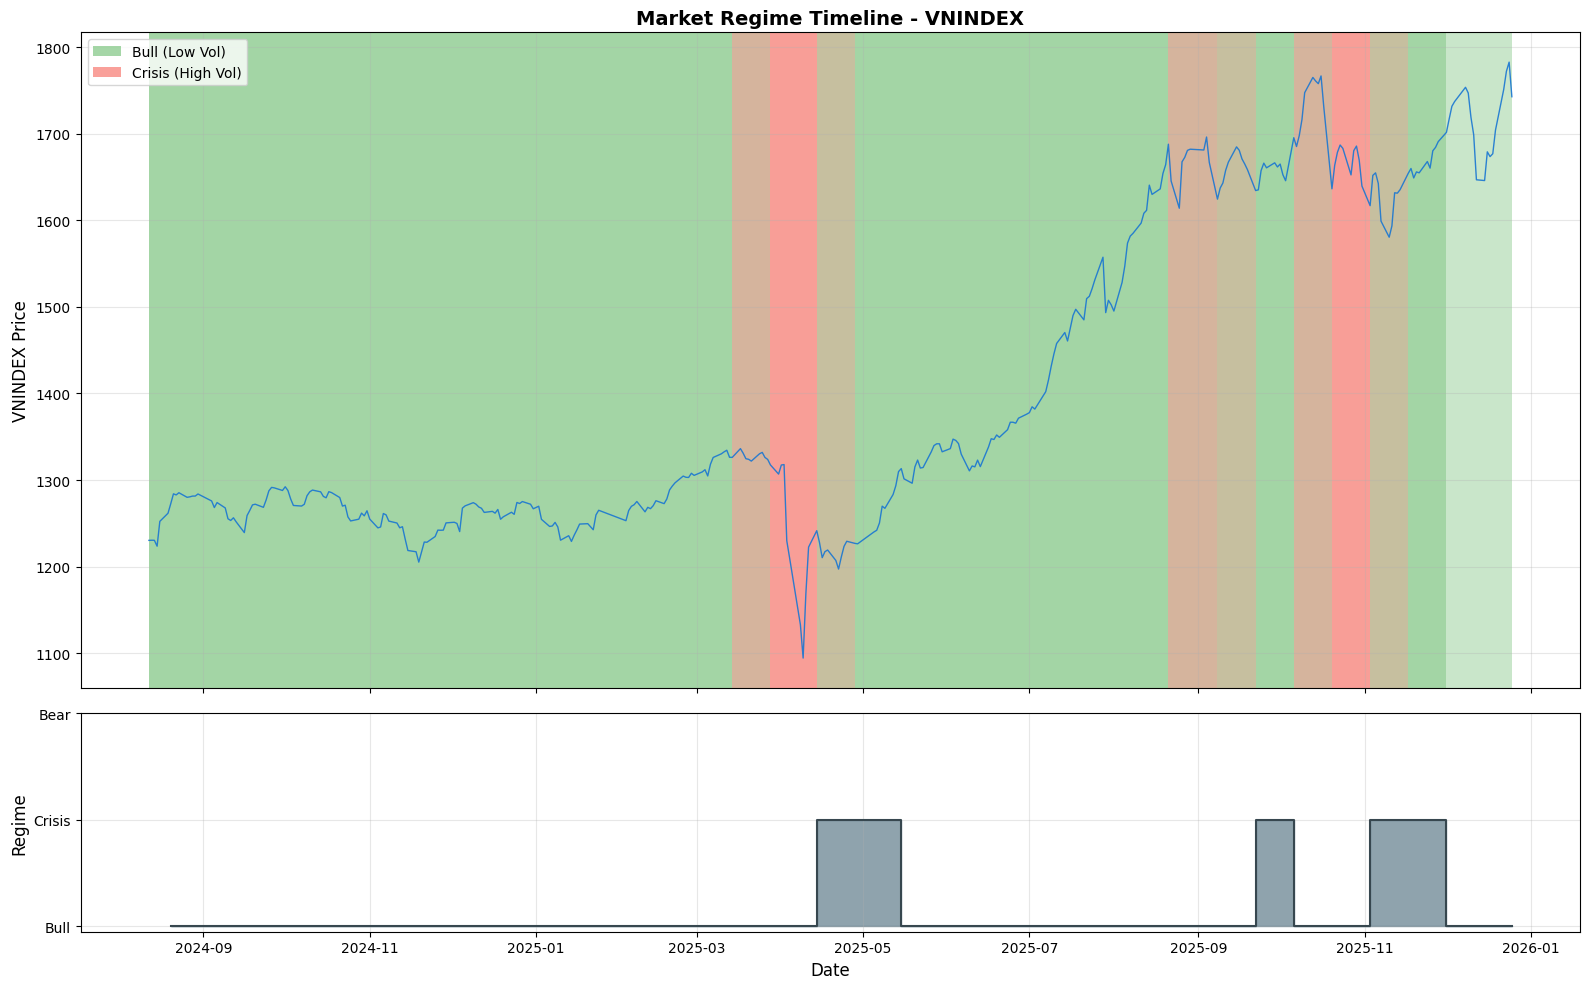


REGIME SUMMARY (Last 500 days)
Bull (Low Vol)      : Mean=+0.15%, Std=0.84%, Count= 29 windows (85.3%)
Crisis (High Vol)   : Mean=-0.19%, Std=2.27%, Count=  5 windows (14.7%)
Last day of data:  2025-12-25 00:00:00


In [44]:
# Plot regime timeline chart - Last 500 days only
last_n_days = 500
cutoff_date = vnindex_close.index[-1] - pd.Timedelta(days=last_n_days)

# Filter data for last 500 days
vnindex_close_filtered = vnindex_close[vnindex_close.index >= cutoff_date]
daily_returns_filtered = daily_returns[daily_returns.index >= cutoff_date]

# Filter segment dates and labels for last 500 days
filtered_indices = [i for i, d in enumerate(segment_dates) if d >= cutoff_date]
segment_dates_filtered = [segment_dates[i] for i in filtered_indices]
labels_filtered = [labels[i] for i in filtered_indices]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                gridspec_kw={'height_ratios': [3, 1]})

# Define regime colors and names based on statistics
regime_colors = {0: '#4CAF50', 1: '#F44336', 2: '#FF9800'}  # Green=Bull, Red=Crisis, Orange=Bear
regime_names = {0: 'Bull (Low Vol)', 1: 'Crisis (High Vol)', 2: 'Bear'}

# Top plot: Price with regime background
ax1.plot(vnindex_close_filtered.index, vnindex_close_filtered.values, color='#1976D2', linewidth=1, alpha=0.9)

# Add colored background for each regime period
for i, (date, label) in enumerate(zip(segment_dates_filtered, labels_filtered)):
    # Get start date of the window
    orig_idx = filtered_indices[i]
    start_idx = max(0, orig_idx * step_size)
    start_date = max(daily_returns.index[start_idx], cutoff_date)
    end_date = date
    
    ax1.axvspan(start_date, end_date, alpha=0.3, color=regime_colors[label], linewidth=0)

# Extend the last regime to cover remaining days (forward-fill)
if len(segment_dates_filtered) > 0:
    last_regime_date = segment_dates_filtered[-1]
    last_regime_label = labels_filtered[-1]
    last_data_date = vnindex_close_filtered.index[-1]
    if last_data_date > last_regime_date:
        ax1.axvspan(last_regime_date, last_data_date, alpha=0.3, 
                    color=regime_colors[last_regime_label], linewidth=0)
        print(f"Note: Extended last regime ({regime_names[last_regime_label]}) from {last_regime_date.date()} to {last_data_date.date()}")

ax1.set_ylabel('VNINDEX Price', fontsize=12)
ax1.set_title('Market Regime Timeline - VNINDEX', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Create legend for regimes
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=regime_colors[i], alpha=0.5, label=regime_names[i]) 
                   for i in range(n_clusters)]
ax1.legend(handles=legend_elements, loc='upper left')

# Bottom plot: Regime indicator as step chart
# Extend to last data date by appending the last regime
regime_series = pd.Series(labels_filtered, index=segment_dates_filtered)
if len(regime_series) > 0 and vnindex_close_filtered.index[-1] > regime_series.index[-1]:
    regime_series = pd.concat([regime_series, pd.Series([labels_filtered[-1]], index=[vnindex_close_filtered.index[-1]])])

ax2.fill_between(regime_series.index, regime_series.values, step='post', alpha=0.7, color='#607D8B')
ax2.step(regime_series.index, regime_series.values, where='post', color='#37474F', linewidth=1.5)

ax2.set_ylabel('Regime', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['Bull', 'Crisis', 'Bear'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also create a summary table for last 500 days
print("\n" + "="*60)
print(f"REGIME SUMMARY (Last {last_n_days} days)")
print("="*60)
for cluster in range(n_clusters):
    cluster_indices = [filtered_indices[i] for i in range(len(filtered_indices)) if labels_filtered[i] == cluster]
    cluster_segments = [segments[idx] for idx in cluster_indices]
    if cluster_segments:
        all_returns = np.concatenate(cluster_segments)
        pct = len(cluster_segments) / len(labels_filtered) * 100
        print(f"{regime_names[cluster]:20s}: Mean={all_returns.mean()*100:+.2f}%, "
              f"Std={all_returns.std()*100:.2f}%, Count={len(cluster_segments):3d} windows ({pct:.1f}%)")
    else:
        print(f"{regime_names[cluster]:20s}: No windows in this period")
print("Last day of data: ", vnindex_close.index[-1])

In [35]:
# =============================================================================
# IMPROVED REGIME DETECTION WITH MULTIPLE FEATURES
# =============================================================================
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# 1. Calculate McClellan Summation Index (Market Breadth)
# -----------------------------------------------------------------------------
# McClellan requires advance/decline data. We'll simulate using stock breadth.
close_prices = df.close.dropna(axis=1, how='all')

# Calculate advancing vs declining stocks
advances = (close_prices.pct_change() > 0).sum(axis=1)
declines = (close_prices.pct_change() < 0).sum(axis=1)
advance_decline = advances - declines

# McClellan Oscillator = EMA(19) - EMA(39) of Advance-Decline
ema_19 = advance_decline.ewm(span=19, adjust=False).mean()
ema_39 = advance_decline.ewm(span=39, adjust=False).mean()
mcclellan_oscillator = ema_19 - ema_39

# McClellan Summation Index = Cumulative sum of McClellan Oscillator
mcclellan_summation = mcclellan_oscillator.cumsum()

# Normalize for easier interpretation
mcclellan_summation_norm = (mcclellan_summation - mcclellan_summation.rolling(252).mean()) / mcclellan_summation.rolling(252).std()

print("McClellan Summation Index calculated!")
print(f"Current value: {mcclellan_summation.iloc[-1]:.2f}")

# -----------------------------------------------------------------------------
# 2. Calculate Additional Indicators
# -----------------------------------------------------------------------------
# Volatility (20-day rolling std)
volatility = daily_returns.rolling(20).std()

# Trend strength (20-day momentum)
momentum = vnindex_close.pct_change(20)

# Market breadth ratio
breadth_ratio = advances / (advances + declines + 1e-6)

# RSI of the index
def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs = gain / (loss + 1e-6)
    return 100 - (100 / (1 + rs))

rsi = calculate_rsi(vnindex_close)

# -----------------------------------------------------------------------------
# 3. Extract Features for Each Window
# -----------------------------------------------------------------------------
window_size = 20
step_size = 10
feature_list = []
feature_dates = []

for i in range(0, len(daily_returns) - window_size, step_size):
    end_idx = i + window_size
    end_date = daily_returns.index[end_idx]
    
    # Return distribution features
    window_returns = daily_returns.iloc[i:end_idx].values
    
    features = {
        # Distribution features
        'mean_return': np.mean(window_returns),
        'volatility': np.std(window_returns),
        'skewness': skew(window_returns),
        'kurtosis': kurtosis(window_returns),
        
        # Technical indicators (end of window values)
        'mcclellan_sum': mcclellan_summation_norm.iloc[end_idx] if end_idx < len(mcclellan_summation_norm) else np.nan,
        'momentum': momentum.iloc[end_idx] if end_idx < len(momentum) else np.nan,
        'breadth': breadth_ratio.iloc[end_idx] if end_idx < len(breadth_ratio) else np.nan,
        'rsi': rsi.iloc[end_idx] if end_idx < len(rsi) else np.nan,
        
        # Trend features
        'trend_direction': 1 if window_returns.mean() > 0 else -1,
        'vol_regime': volatility.iloc[end_idx] if end_idx < len(volatility) else np.nan,
    }
    
    feature_list.append(features)
    feature_dates.append(end_date)

# Convert to DataFrame
features_df = pd.DataFrame(feature_list, index=feature_dates)
features_df = features_df.dropna()

print(f"\nFeature matrix shape: {features_df.shape}")
print(f"Features: {list(features_df.columns)}")
features_df.tail()


McClellan Summation Index calculated!
Current value: -167.14

Feature matrix shape: (224, 10)
Features: ['mean_return', 'volatility', 'skewness', 'kurtosis', 'mcclellan_sum', 'momentum', 'breadth', 'rsi', 'trend_direction', 'vol_regime']


,mean_return,volatility,skewness,kurtosis,mcclellan_sum,momentum,breadth,rsi,trend_direction,vol_regime
2025-10-20,0.002204,0.011017,0.398681,0.569333,-0.578276,0.043753,0.213483,64.788121,1,0.016714
2025-11-03,-0.000025,0.017912,-1.201507,2.090750,-0.789761,-0.003749,0.346154,29.835101,-1,0.017164
2025-11-17,-0.002676,0.018007,-0.965140,1.271936,-0.959146,-0.055297,0.610063,46.838424,-1,0.014064
2025-12-01,0.001608,0.011422,-0.260283,0.413450,-0.974561,0.031312,0.280702,86.696769,1,0.011177
2025-12-15,0.000400,0.010156,-1.498218,2.055894,-1.249617,0.006989,0.057895,44.926634,1,0.010081


In [37]:
# =============================================================================
# 4. Cluster on Multi-Feature Space
# =============================================================================
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Standardize features (important for clustering!)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_df)

# Try different numbers of clusters and evaluate
print("Evaluating optimal number of clusters...")
silhouette_scores = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels_temp)
    silhouette_scores.append((k, score))
    print(f"  k={k}: Silhouette Score = {score:.4f}")

best_k = max(silhouette_scores, key=lambda x: x[1])[0]
print(f"\nOptimal clusters: {best_k}")

# Final clustering with optimal k
n_clusters_improved = best_k
kmeans_improved = KMeans(n_clusters=n_clusters_improved, random_state=42, n_init=10)
labels_improved = kmeans_improved.fit_predict(features_scaled)

# Alternative: Gaussian Mixture Model (soft clustering, handles elliptical clusters better)
gmm = GaussianMixture(n_components=n_clusters_improved, random_state=42, covariance_type='full')
labels_gmm = gmm.fit_predict(features_scaled)
gmm_probs = gmm.predict_proba(features_scaled)

print(f"\nGMM cluster probabilities shape: {gmm_probs.shape}")

# Add labels to features dataframe
features_df['regime_kmeans'] = labels_improved
features_df['regime_gmm'] = labels_gmm

# Analyze regime characteristics
print("\n" + "="*70)
print("REGIME CHARACTERISTICS (Feature-Based)")
print("="*70)
for regime in range(n_clusters_improved):
    mask = features_df['regime_kmeans'] == regime
    regime_data = features_df[mask]
    print(f"\nRegime {regime} ({mask.sum()} windows):")
    print(f"  Mean Return:    {regime_data['mean_return'].mean()*100:+.3f}%")
    print(f"  Volatility:     {regime_data['volatility'].mean()*100:.3f}%")
    print(f"  McClellan Sum:  {regime_data['mcclellan_sum'].mean():+.2f}")
    print(f"  Momentum:       {regime_data['momentum'].mean()*100:+.2f}%")
    print(f"  Breadth:        {regime_data['breadth'].mean():.2%}")
    print(f"  RSI:            {regime_data['rsi'].mean():.1f}")


Evaluating optimal number of clusters...
  k=2: Silhouette Score = 0.2901
  k=3: Silhouette Score = 0.2315
  k=4: Silhouette Score = 0.2379
  k=5: Silhouette Score = 0.2211

Optimal clusters: 2

GMM cluster probabilities shape: (224, 2)

REGIME CHARACTERISTICS (Feature-Based)

Regime 0 (82 windows):
  Mean Return:    -0.221%
  Volatility:     1.351%
  McClellan Sum:  -0.76
  Momentum:       -4.43%
  Breadth:        45.89%
  RSI:            40.1

Regime 1 (142 windows):
  Mean Return:    +0.204%
  Volatility:     0.828%
  McClellan Sum:  +0.37
  Momentum:       +4.12%
  Breadth:        50.32%
  RSI:            65.7


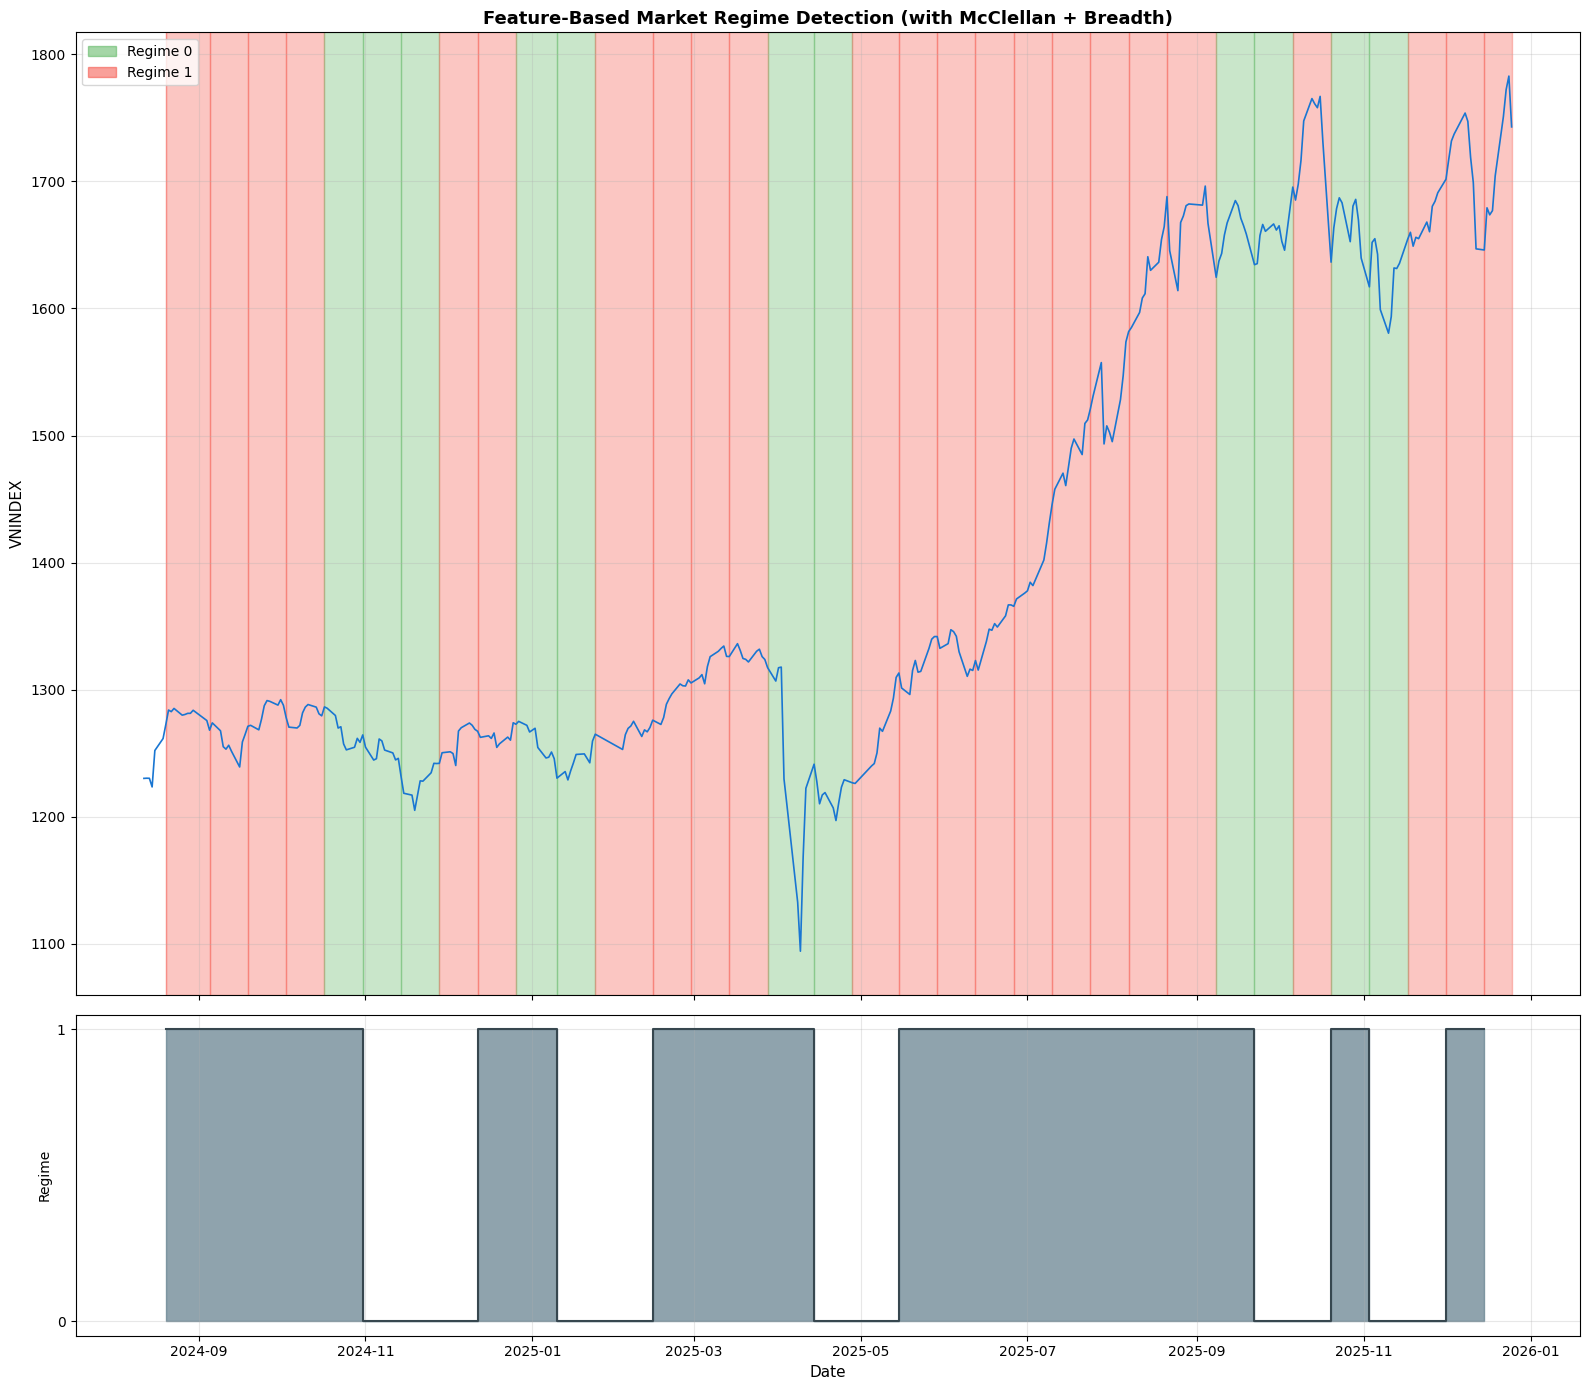


Current Regime: 1
Current McClellan: -1.30
Current Breadth: 16.13%


In [42]:
# =============================================================================
# 5. Visualize Improved Regime Detection (Last 500 days)
# =============================================================================
last_n_days = 500
cutoff_date = vnindex_close.index[-1] - pd.Timedelta(days=last_n_days)

# Filter features_df for visualization
features_filtered = features_df[features_df.index >= cutoff_date].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# Color scheme for regimes
regime_colors_improved = ['#4CAF50', '#F44336', '#FF9800', '#2196F3', '#9C27B0']

# 1. Price with regime background
ax1 = axes[0]
vnindex_filtered = vnindex_close[vnindex_close.index >= cutoff_date]
ax1.plot(vnindex_filtered.index, vnindex_filtered.values, color='#1976D2', linewidth=1.2)

# Add regime backgrounds
prev_date = features_filtered.index[0]
for date, row in features_filtered.iterrows():
    regime = int(row['regime_kmeans'])
    ax1.axvspan(prev_date, date, alpha=0.3, color=regime_colors_improved[regime])
    prev_date = date

# Extend to last date
if features_filtered.index[-1] < vnindex_filtered.index[-1]:
    last_regime = int(features_filtered['regime_kmeans'].iloc[-1])
    ax1.axvspan(features_filtered.index[-1], vnindex_filtered.index[-1], 
                alpha=0.3, color=regime_colors_improved[last_regime])

ax1.set_ylabel('VNINDEX', fontsize=11)
ax1.set_title('Feature-Based Market Regime Detection (with McClellan + Breadth)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=regime_colors_improved[i], alpha=0.5, label=f'Regime {i}') 
                  for i in range(n_clusters_improved)]
ax1.legend(handles=legend_patches, loc='upper left')

# 4. Regime indicator
ax4 = axes[1]
regime_series = features_filtered['regime_kmeans']
ax4.fill_between(regime_series.index, regime_series.values, step='post', alpha=0.7, color='#607D8B')
ax4.step(regime_series.index, regime_series.values, where='post', color='#37474F', linewidth=1.5)
ax4.set_ylabel('Regime', fontsize=10)
ax4.set_xlabel('Date', fontsize=11)
ax4.set_yticks(range(n_clusters_improved))
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCurrent Regime: {features_filtered['regime_kmeans'].iloc[-1]}")
print(f"Current McClellan: {mcclellan_summation_norm.iloc[-1]:.2f}")
print(f"Current Breadth: {breadth_ratio.iloc[-1]:.2%}")


In [45]:
# =============================================================================
# REAL-TIME REGIME DETECTION (Production-Ready Approach)
# =============================================================================
# The key insight: Train on HISTORICAL data, apply to CURRENT data without refitting

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import skew, kurtosis
import pickle

# -----------------------------------------------------------------------------
# Step 1: Define the training period (e.g., first 80% of data)
# -----------------------------------------------------------------------------
train_ratio = 0.8
train_end_idx = int(len(features_df) * train_ratio)

train_data = features_df.iloc[:train_end_idx].copy()
test_data = features_df.iloc[train_end_idx:].copy()  # "Future" data for validation

print(f"Training period: {train_data.index[0].date()} to {train_data.index[-1].date()}")
print(f"Test period:     {test_data.index[0].date()} to {test_data.index[-1].date()}")
print(f"Training samples: {len(train_data)}, Test samples: {len(test_data)}")

# -----------------------------------------------------------------------------
# Step 2: Fit scaler and clusterer on TRAINING data only
# -----------------------------------------------------------------------------
feature_cols = ['mean_return', 'volatility', 'skewness', 'kurtosis', 
                'mcclellan_sum', 'momentum', 'breadth', 'rsi', 'vol_regime']

# Fit scaler on training data
scaler_realtime = StandardScaler()
train_scaled = scaler_realtime.fit_transform(train_data[feature_cols])

# Fit KMeans on training data
n_clusters_realtime = 3
kmeans_realtime = KMeans(n_clusters=n_clusters_realtime, random_state=42, n_init=10)
kmeans_realtime.fit(train_scaled)

train_labels = kmeans_realtime.labels_
print(f"\nCluster distribution in training: {np.bincount(train_labels)}")

# -----------------------------------------------------------------------------
# Step 3: Apply to test data WITHOUT refitting (real-time simulation)
# -----------------------------------------------------------------------------
test_scaled = scaler_realtime.transform(test_data[feature_cols])  # transform, not fit_transform!
test_labels = kmeans_realtime.predict(test_scaled)  # predict, not fit_predict!

print(f"Cluster distribution in test: {np.bincount(test_labels)}")

# Add labels
train_data['regime_realtime'] = train_labels
test_data['regime_realtime'] = test_labels

# Combine for visualization
all_data_realtime = pd.concat([train_data, test_data])

# -----------------------------------------------------------------------------
# Step 4: Validate - do regimes have consistent characteristics?
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("REGIME CONSISTENCY CHECK")
print("="*70)
print("\nTraining Period Characteristics:")
for r in range(n_clusters_realtime):
    mask = train_data['regime_realtime'] == r
    if mask.sum() > 0:
        print(f"  Regime {r}: Mean={train_data.loc[mask, 'mean_return'].mean()*100:+.2f}%, "
              f"Vol={train_data.loc[mask, 'volatility'].mean()*100:.2f}%, "
              f"Count={mask.sum()}")

print("\nTest Period Characteristics (should be similar!):")
for r in range(n_clusters_realtime):
    mask = test_data['regime_realtime'] == r
    if mask.sum() > 0:
        print(f"  Regime {r}: Mean={test_data.loc[mask, 'mean_return'].mean()*100:+.2f}%, "
              f"Vol={test_data.loc[mask, 'volatility'].mean()*100:.2f}%, "
              f"Count={mask.sum()}")

# -----------------------------------------------------------------------------
# Current regime detection
# -----------------------------------------------------------------------------
current_features = features_df[feature_cols].iloc[-1:].values
current_scaled = scaler_realtime.transform(current_features)
current_regime = kmeans_realtime.predict(current_scaled)[0]

print("\n" + "="*70)
print(f"🎯 CURRENT MARKET REGIME: {current_regime}")
print("="*70)


Training period: 2017-01-11 to 2024-02-28
Test period:     2024-03-13 to 2025-12-15
Training samples: 179, Test samples: 45

Cluster distribution in training: [109  38  32]
Cluster distribution in test: [33  5  7]

REGIME CONSISTENCY CHECK

Training Period Characteristics:
  Regime 0: Mean=+0.15%, Vol=0.74%, Count=109
  Regime 1: Mean=-0.35%, Vol=1.77%, Count=38
  Regime 2: Mean=+0.15%, Vol=1.17%, Count=32

Test Period Characteristics (should be similar!):
  Regime 0: Mean=+0.13%, Vol=0.73%, Count=33
  Regime 1: Mean=-0.33%, Vol=2.05%, Count=5
  Regime 2: Mean=+0.13%, Vol=1.30%, Count=7

🎯 CURRENT MARKET REGIME: 2


In [ ]:
# =============================================================================
# PRODUCTION: Save model for real-time use
# =============================================================================

# Save the trained model and scaler
model_artifacts = {
    'scaler': scaler_realtime,
    'kmeans': kmeans_realtime,
    'feature_cols': feature_cols,
    'n_clusters': n_clusters_realtime,
    'training_end_date': train_data.index[-1],
    'regime_descriptions': {
        # You should update these based on your analysis
        0: 'Unknown - check characteristics',
        1: 'Unknown - check characteristics', 
        2: 'Unknown - check characteristics',
    }
}

# Save to file
with open('regime_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)
print("Model saved to regime_model.pkl")

# -----------------------------------------------------------------------------
# Example: How to use in production
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("PRODUCTION USAGE EXAMPLE")
print("="*70)
print("""
# Load model
with open('regime_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Calculate features for today's window (last 20 days)
today_features = {
    'mean_return': daily_returns[-20:].mean(),
    'volatility': daily_returns[-20:].std(),
    'skewness': skew(daily_returns[-20:]),
    'kurtosis': kurtosis(daily_returns[-20:]),
    'mcclellan_sum': mcclellan_summation_norm.iloc[-1],
    'momentum': momentum.iloc[-1],
    'breadth': breadth_ratio.iloc[-1],
    'rsi': rsi.iloc[-1],
    'vol_regime': volatility.iloc[-1],
}

# Predict
features_array = np.array([[today_features[col] for col in model['feature_cols']]])
features_scaled = model['scaler'].transform(features_array)
current_regime = model['kmeans'].predict(features_scaled)[0]
print(f"Current Regime: {current_regime}")
""")
